In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

## Частина 1. Огляд та попередній аналіз даних


In [2]:
df = pd.read_csv('bank.csv')

print(df.shape)
df.info()


(11162, 17)
<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
null_counts = df.isnull().sum()
duplicate_count = df.duplicated().sum()

print(f"Пропуски: {null_counts.sum()}")
print(f"Дублі: {duplicate_count}")

unknown_counts = {}
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    cnt = (df[col] == 'unknown').sum()
    if cnt > 0:
        unknown_counts[col] = cnt
        print(f"{col}': {cnt} unknowns ({round(cnt / df.shape[0] * 100, 2)}%)")


Пропуски: 0
Дублі: 0
job': 70 unknowns (0.63%)
education': 497 unknowns (4.45%)
contact': 2346 unknowns (21.02%)
poutcome': 8326 unknowns (74.59%)


C:\Users\gkhar\AppData\Local\Temp\ipykernel_5576\381173427.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [6]:
df.describe(include=['object'])

C:\Users\gkhar\AppData\Local\Temp\ipykernel_5576\3011300674.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


In [7]:
df['deposit'].value_counts()


deposit
no     5873
yes    5289
Name: count, dtype: int64

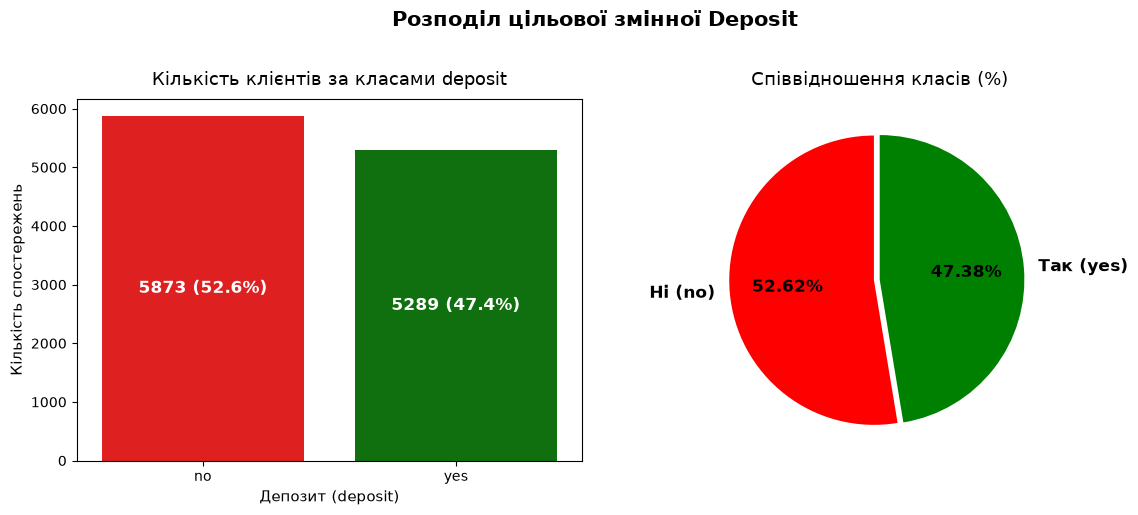

In [8]:
counts = df['deposit'].value_counts()
props = df['deposit'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['red', 'green']

sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=colors, legend=False, ax=axes[0])
axes[0].set_title('Кількість клієнтів за класами deposit', fontsize=13, pad=10)
axes[0].set_xlabel('Депозит (deposit)', fontsize=11)
axes[0].set_ylabel('Кількість спостережень', fontsize=11)

for i, (v, p) in enumerate(zip(counts.values, props.values)):
    axes[0].annotate(f'{v} ({p:.1f}%)', (i, v / 2), 
                     ha='center', va='center', color='white', weight='bold', fontsize=12)

axes[1].pie(counts, labels=['Ні (no)', 'Так (yes)'], autopct='%1.2f%%', 
             colors=colors, startangle=90, explode=(0.04, 0), 
             textprops={'fontsize': 12, 'weight': 'bold'})
axes[1].set_title('Співвідношення класів (%)', fontsize=13, pad=10)
plt.suptitle('Розподіл цільової змінної Deposit', fontsize=15, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

Датасет містить 11 162 рядки та 17 колонок (7 числових та 10 категоріальних ознак). Явні пропуски (Null/NaN) і повні дублікати рядків у даних відсутні (0 пропусків по всіх 17 колонках та 0 повторів).

Категоріальні ознаки містять неявні пропуски у вигляді значення 'unknown': poutcome (74.59%), contact (21.02%), education (4.45%) та job (0.63%). Це значення можна розглядати як повноцінну категорію, адже воно може свідчити про відсутність попередньої взаємодії з банком

Цільова змінна deposit є майже ідеально збалансованою: 5 873 клієнтів (52.62%) відмовилися від депозиту (no), а 5 289 клієнтів (47.38%) відкрили депозит (yes)

## Частина 2. Візуалізація даних


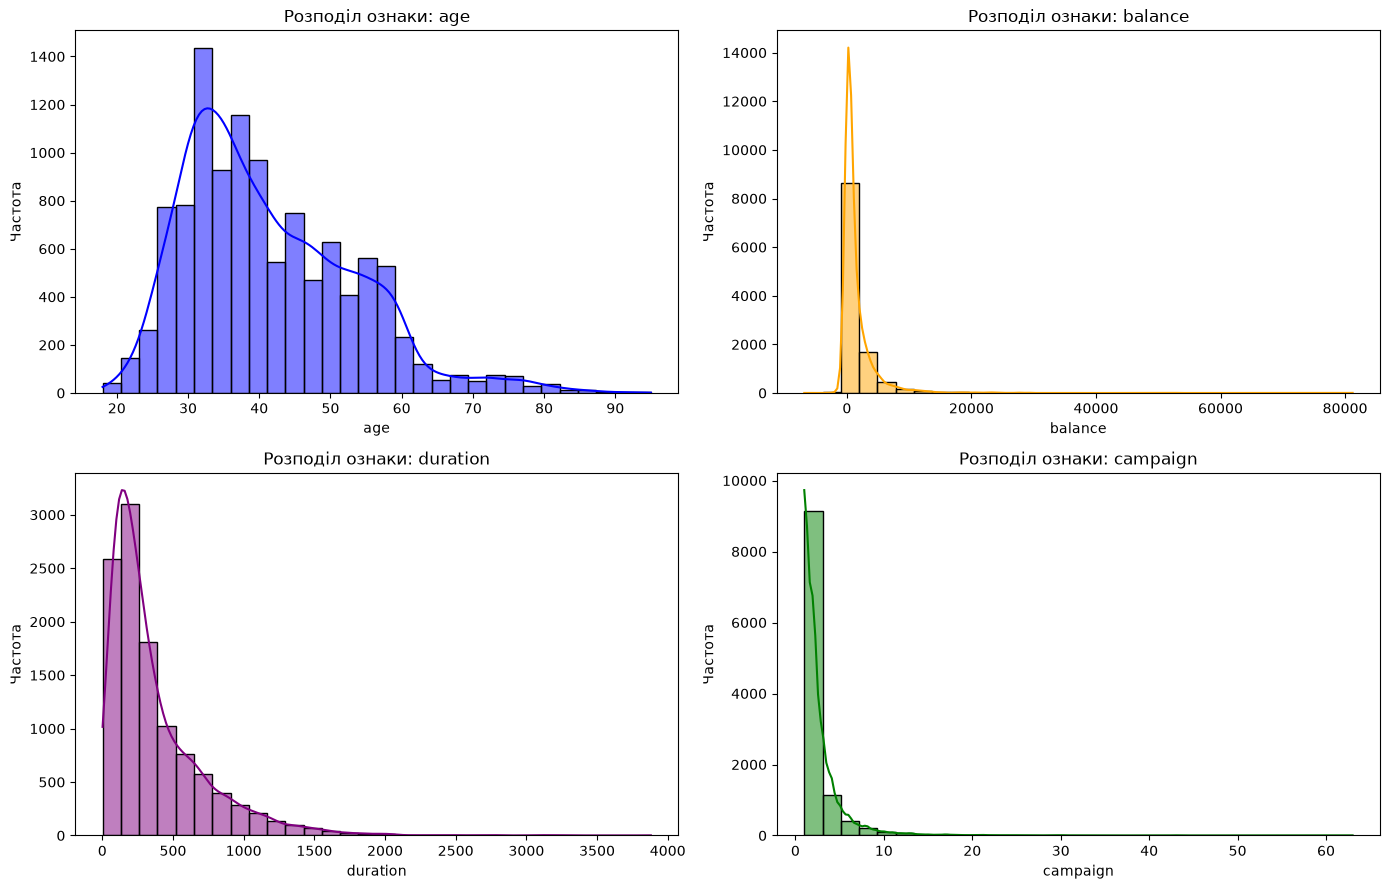

In [9]:
# розподіли ключових числових ознак

num_cols = ['age', 'balance', 'duration', 'campaign']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

colors = ['blue', 'orange', 'purple', 'green']

for idx, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color=colors[idx], bins=30)
    axes[idx].set_title(f'Розподіл ознаки: {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Частота')

plt.tight_layout()
plt.show()


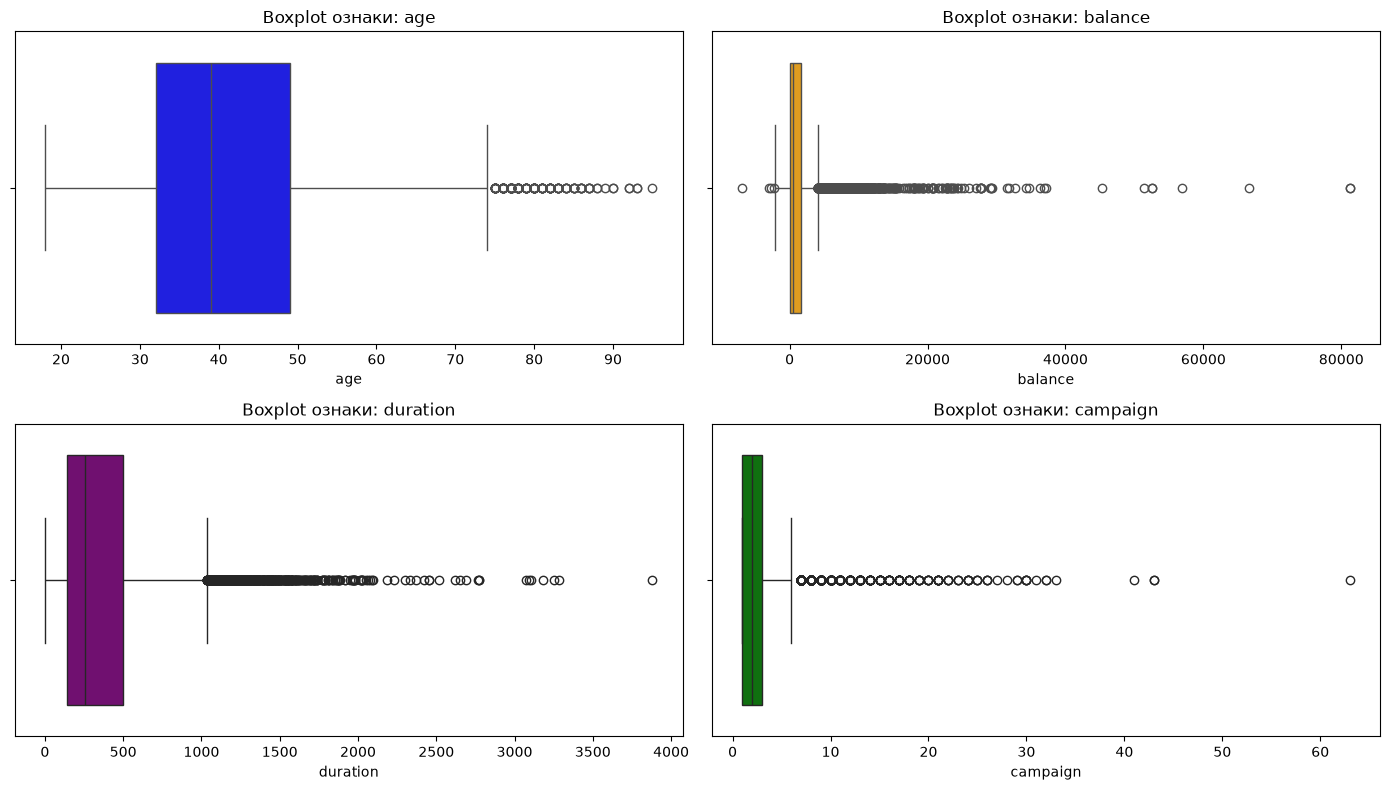

In [10]:
# Boxplot

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color=colors[idx])
    axes[idx].set_title(f'Boxplot ознаки: {col}')
    axes[idx].set_xlabel(col)

plt.tight_layout()
plt.show()


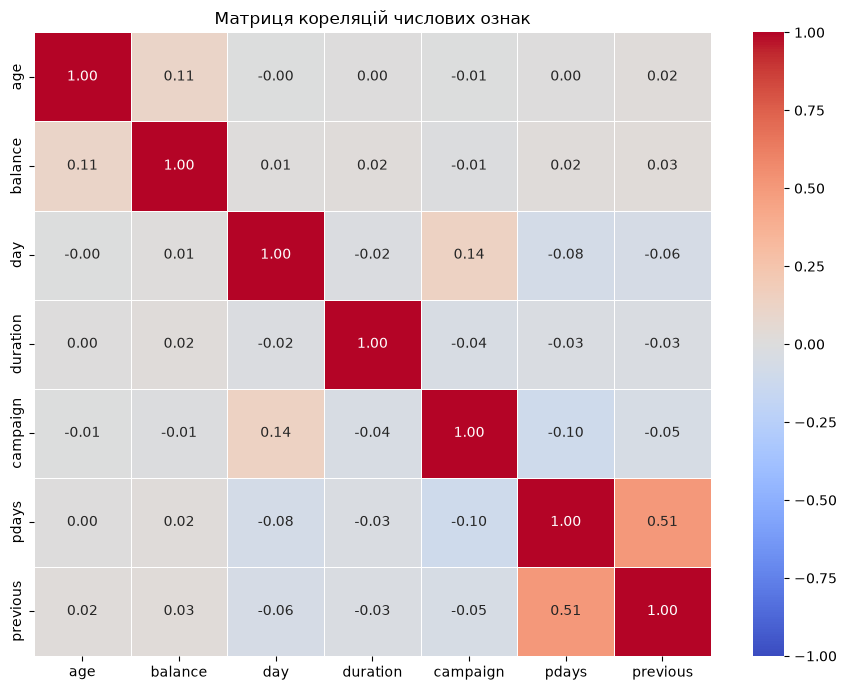

In [11]:
# Heatmap кореляцій числових ознак

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Матриця кореляцій числових ознак')
plt.tight_layout()
plt.show()


C:\Users\gkhar\AppData\Local\Temp\ipykernel_5576\288835216.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='deposit', y='duration', palette=['green', 'red'], ax=axes[0, 0])


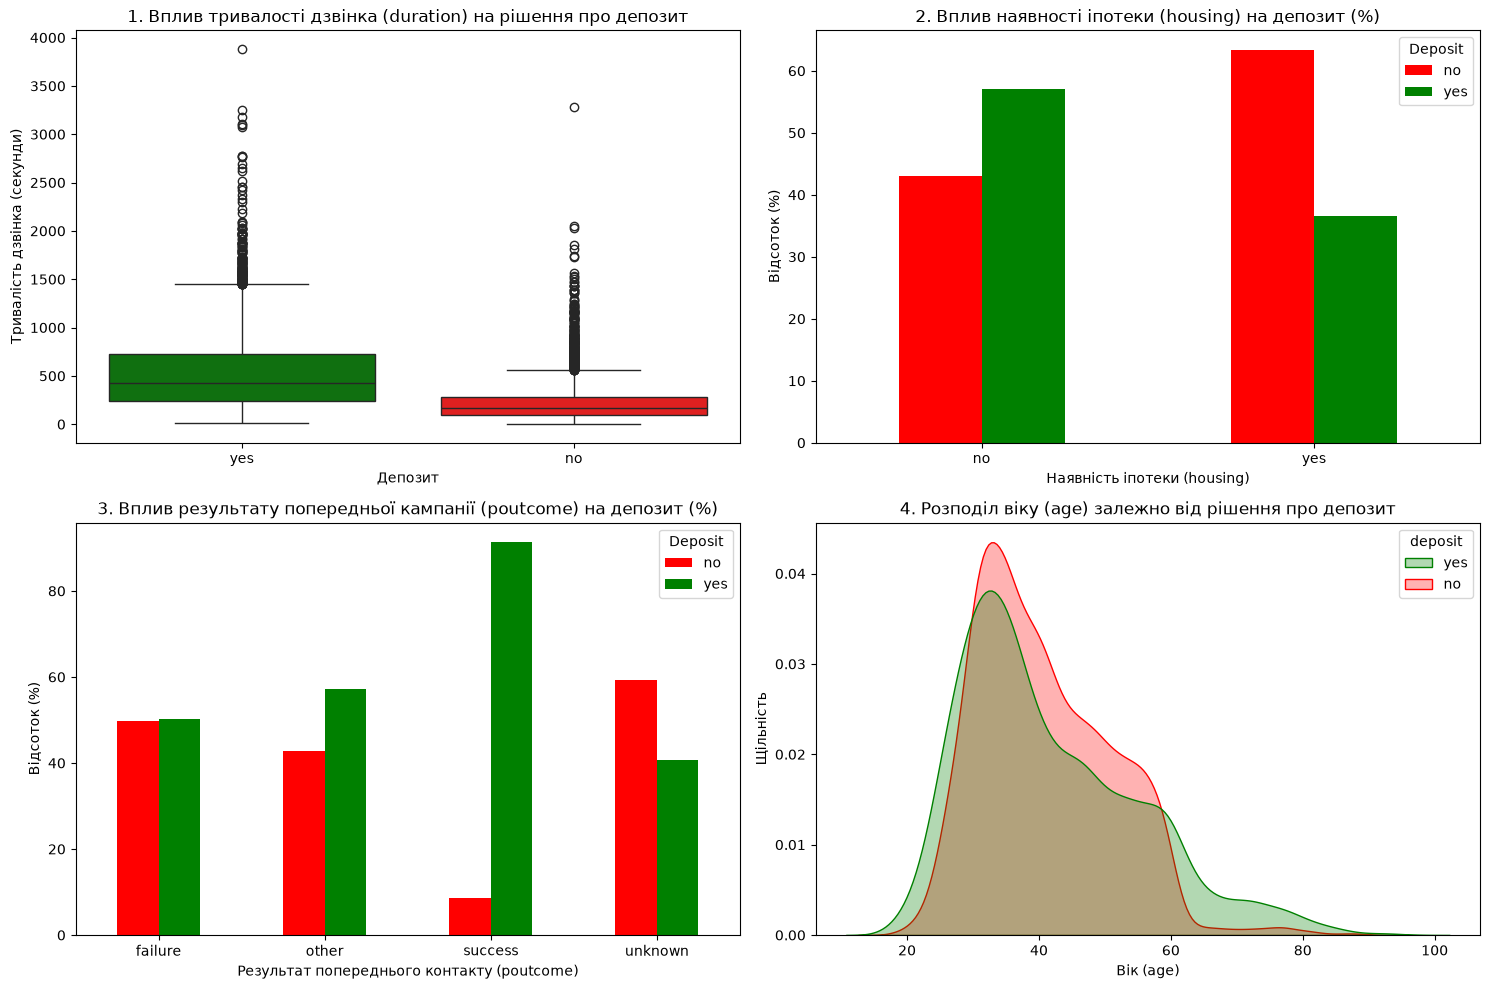

In [12]:
# Залежність цільової змінної від key features: duration, housing, poutcome, age

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Duration vs Deposit (Boxplot)
sns.boxplot(data=df, x='deposit', y='duration', palette=['green', 'red'], ax=axes[0, 0])
axes[0, 0].set_title('1. Вплив тривалості дзвінка (duration) на рішення про депозит')
axes[0, 0].set_xlabel('Депозит')
axes[0, 0].set_ylabel('Тривалість дзвінка (секунди)')

# 2. Housing Loan vs Deposit Rate
housing_dep = pd.crosstab(df['housing'], df['deposit'], normalize='index') * 100
housing_dep.plot(kind='bar', stacked=False, color=['red', 'green'], ax=axes[0, 1], rot=0)
axes[0, 1].set_title('2. Вплив наявності іпотеки (housing) на депозит (%)')
axes[0, 1].set_xlabel('Наявність іпотеки (housing)')
axes[0, 1].set_ylabel('Відсоток (%)')
axes[0, 1].legend(title='Deposit')

# 3. Previous Outcome (poutcome) vs Deposit Rate
poutcome_dep = pd.crosstab(df['poutcome'], df['deposit'], normalize='index') * 100
poutcome_dep.plot(kind='bar', stacked=False, color=['red', 'green'], ax=axes[1, 0], rot=0)
axes[1, 0].set_title('3. Вплив результату попередньої кампанії (poutcome) на депозит (%)')
axes[1, 0].set_xlabel('Результат попереднього контакту (poutcome)')
axes[1, 0].set_ylabel('Відсоток (%)')
axes[1, 0].legend(title='Deposit')

# 4. Age distribution by Deposit
sns.kdeplot(data=df, x='age', hue='deposit', common_norm=False, palette=['green', 'red'], 
            fill=True, alpha=0.3, ax=axes[1, 1])
axes[1, 1].set_title('4. Розподіл віку (age) залежно від рішення про депозит')
axes[1, 1].set_xlabel('Вік (age)')
axes[1, 1].set_ylabel('Щільність')

plt.tight_layout()
plt.show()


C:\Users\gkhar\AppData\Local\Temp\ipykernel_5576\4222808488.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_temp.select_dtypes(include=['object']).columns.drop('deposit')


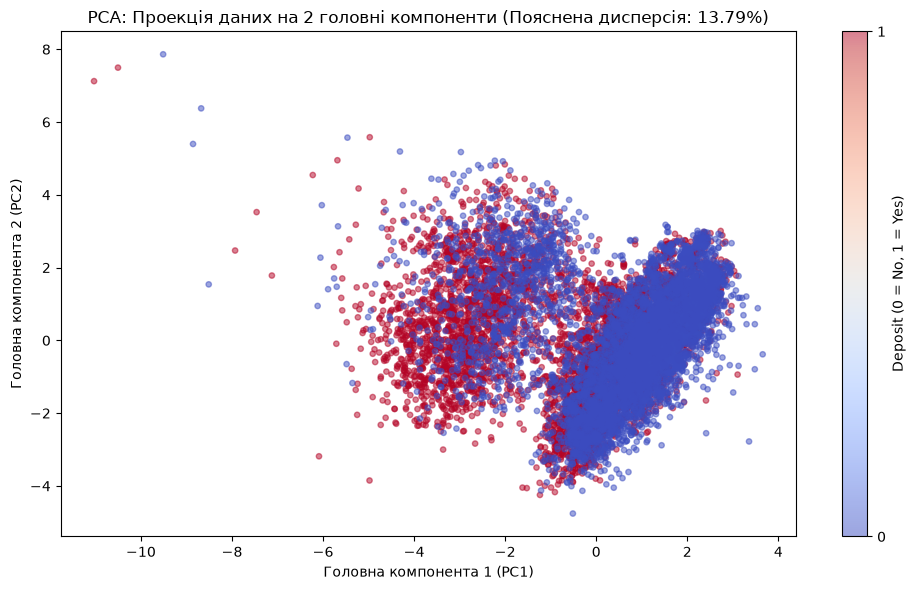

In [13]:
# Візуалізація після зниження розмірності (PCA 2D)

# Тимчасова підготовка даних для PCA
df_temp = df.copy()
cat_cols = df_temp.select_dtypes(include=['object']).columns.drop('deposit')
df_encoded_temp = pd.get_dummies(df_temp, columns=cat_cols, drop_first=True)
df_encoded_temp['deposit_num'] = (df_encoded_temp['deposit'] == 'yes').astype(int)

X_pca_input = df_encoded_temp.drop(['deposit', 'deposit_num'], axis=1)
X_scaled_temp = StandardScaler().fit_transform(X_pca_input)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_temp)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_encoded_temp['deposit_num'], 
                      cmap='coolwarm', alpha=0.5, s=15)
plt.colorbar(scatter, ticks=[0, 1], label='Deposit (0 = No, 1 = Yes)')
plt.title(f'PCA: Проекція даних на 2 головні компоненти (Пояснена дисперсія: {pca.explained_variance_ratio_.sum()*100:.2f}%)')
plt.xlabel('Головна компонента 1 (PC1)')
plt.ylabel('Головна компонента 2 (PC2)')
plt.tight_layout()
plt.show()


### Висновки до Частини 2:
1. **Розподіли змінних**: Змінні balance, duration, campaign, pdays, previous мають виражену правосторонню асиметрію та значну кількість викидів.
2. **Викиди (Outliers)**: Наприклад, balance містить екстремальні значення від від'ємних (-6,847) до понад 80,000. duration має значення понад 3,000 секунд. 
3. **Залежність цільової змінної**:
   - **duration**: Один із найсильніших факторів. Чим довша розмова з клієнтом, тим вища ймовірність відкриття депозиту.
   - **housing**: Клієнти без іпотеки (housing='no') значно частіше підписуються на депозит (~57%), ніж клієнти з іпотекою (~36%).
   - **poutcome**: Якщо попередня маркетингова кампанія була успішною (poutcome='success'), ймовірність оформлення депозиту перевищує 86%
   - **age**: Молодші клієнти (<30 років) та старші клієнти (>60 років) мають вищу конверсію у відкриття депозиту порівняно з середньою віковою групою (30–50 років).
4. **PCA візуалізація**: Проекція на 2 компоненти показує часткове розділення класів, що свідчить про наявність нелінійних залежностей у даних


## Частина 3. Попередня обробка даних та Feature Engineering

In [14]:
# Feature Engineering
df_fe = df.copy()

# 1. pdays_contacted: Прапорець чи контактували з клієнтом у попередніх кампаніях (pdays != -1)
df_fe['pdays_contacted'] = (df_fe['pdays'] != -1).astype(int)

# 2. total_contacts: Загальна кількість контактів (поточна + попередні кампанії)
df_fe['total_contacts'] = df_fe['campaign'] + df_fe['previous']

# 3. is_negative_balance: Прапорець від'ємного балансу (фінансова скрута)
df_fe['is_negative_balance'] = (df_fe['balance'] < 0).astype(int)

# 4. duration_min: Тривалість розмови у хвилинах (зручніша шкала)
df_fe['duration_min'] = df_fe['duration'] / 60.0

print(df_fe[['pdays_contacted', 'total_contacts', 'is_negative_balance', 'duration_min']].head())


   pdays_contacted  total_contacts  is_negative_balance  duration_min
0                0               1                    0     17.366667
1                0               1                    0     24.450000
2                0               1                    0     23.150000
3                0               1                    0      9.650000
4                0               2                    0     11.216667


In [15]:
# 3.2 Кодування категоріальних ознак та підготовка X, y

# Перетворення цільової змінної deposit у двозначну числову: yes -> 1, no -> 0
y = (df_fe['deposit'] == 'yes').astype(int)
X_raw = df_fe.drop('deposit', axis=1)

# Виділення бінарних категоріальних ознак та кодування (default, housing, loan)
binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    X_raw[col] = (X_raw[col] == 'yes').astype(int)

# Multi-class категоріальні ознаки для One-Hot Encoding
multi_cat_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
X_encoded = pd.get_dummies(X_raw, columns=multi_cat_cols, drop_first=True)

print(f"Формат вихідної матриці ознак після кодування: {X_encoded.shape}")

Формат вихідної матриці ознак після кодування: (11162, 46)


In [16]:
# Розподіл даних на Train / Validation / Test та правильне масштабування

# Розподіл: 70% Train, 15% Validation, 15% Test з фіксованим random_state та стратифікацією

X_train, X_val_test, y_train, y_val_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test, test_size=0.5, random_state=42, stratify=y_val_test
)

print(f"Розміри вибірок:")
print(f"Train:      {X_train.shape[0]} рядків ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} рядків ({X_val.shape[0]/len(df)*100:.1f}%)")
print(f"Test:       {X_test.shape[0]} рядків ({X_test.shape[0]/len(df)*100:.1f}%)")

num_to_scale = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 
                'total_contacts', 'duration_min']

scaler = StandardScaler()

scaler.fit(X_train[num_to_scale])

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_to_scale] = scaler.transform(X_train[num_to_scale])
X_val_scaled[num_to_scale] = scaler.transform(X_val[num_to_scale])
X_test_scaled[num_to_scale] = scaler.transform(X_test[num_to_scale])


Розміри вибірок:
Train:      7813 рядків (70.0%)
Validation: 1674 рядків (15.0%)
Test:       1675 рядків (15.0%)


### Пояснення прийнятих рішень у Частині 3:
1. **Обробка пропусків та дублікатів**: Оскільки явні NaN відсутні, а значення 'unknown' в категоріальних ознаках задизайнені банківською системою (наприклад, відсутність попереднього контакту), ми зберегли категорію 'unknown' як окреме кодоване значення під час One-Hot Encoding.
2. **Feature Engineering**:
   - pdays_contacted: Відрізняє первинних клієнтів від тих, з якими банк уже взаємодіяв раніше.
   - total_contacts: Показує загальну кількість взаємодій з клієнтом, що допомагає оцінити втому або активність клієнта.
   - is_negative_balance: Фінансовий індикатор (від'ємний овердрафт чи борг).
   - duration_min: Масштабування розмови у хвилини для полегшення інтерпретації.
3. **Запобігання Data Leakage**: Масштабування StandardScaler підганялося (fit) виключно на навчальній вибірці X_train


## Частина 4. Кластеризація (K-Means)


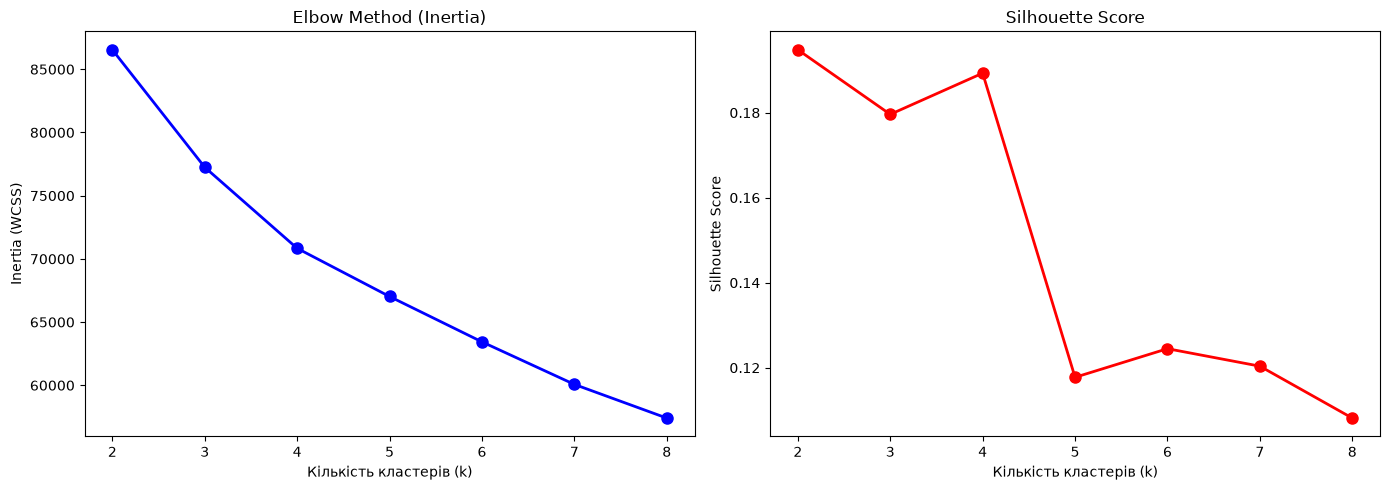

k = 2: Silhouette Score = 0.1948
k = 3: Silhouette Score = 0.1796
k = 4: Silhouette Score = 0.1893
k = 5: Silhouette Score = 0.1178
k = 6: Silhouette Score = 0.1245
k = 7: Silhouette Score = 0.1204
k = 8: Silhouette Score = 0.1082


In [17]:
# Вибір кількості кластерів k (Elbow Method & Silhouette Score)

X_cluster = X_train_scaled.copy()

inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertias.append(kmeans.inertia_)
    score = silhouette_score(X_cluster, kmeans.labels_)
    silhouette_scores.append(score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method Plot
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Кількість кластерів (k)')
axes[0].set_ylabel('Inertia (WCSS)')

# Silhouette Score Plot
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Кількість кластерів (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

for k, score in zip(k_range, silhouette_scores):
    print(f"k = {k}: Silhouette Score = {score:.4f}")


За методом Elbow оптимальна кількість кластерів становить 4, оскільки після цього значення зменшення WCSS стає менш значним. Метод Silhouette показує найбільше значення при k = 2, однак для k = 4 коефіцієнт силуету залишається майже таким самим, після чого різко зменшується. З огляду на результати обох методів було обрано 4 кластери як найкращий компроміс між якістю кластеризації та деталізацією структури даних.

In [18]:
# Побудова фінальної моделі K-Means з k = 4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster)

# Додаємо мітки кластерів до необробленої навчальної вибірки для зрозумілої інтерпретації
df_train_profile = df_fe.loc[X_train.index].copy()
df_train_profile['cluster'] = cluster_labels

print("Кількість клієнтів у кожному кластері")
print(df_train_profile['cluster'].value_counts())

print("Середні значення ключових ознак у кластерах")
cluster_summary = df_train_profile.groupby('cluster')[['age', 'balance', 'duration', 'campaign', 
                                                       'pdays', 'previous', 'pdays_contacted', 'deposit']].apply(
    lambda g: pd.Series({
        'Вік (age)': g['age'].mean(),
        'Баланс (balance)': g['balance'].mean(),
        'Тривалість (duration, сек)': g['duration'].mean(),
        'Контакти (campaign)': g['campaign'].mean(),
        'Попередні контакти (previous)': g['previous'].mean(),
        'Раніше контактували (%)': g['pdays_contacted'].mean() * 100,
        'Конверсія в депозит (%)': (g['deposit'] == 'yes').mean() * 100
    })
)

display(cluster_summary)

Кількість клієнтів у кожному кластері
cluster
1    4499
3    1818
0    1243
2     253
Name: count, dtype: int64
Середні значення ключових ознак у кластерах


,Вік (age),Баланс (balance),"Тривалість (duration, сек)",Контакти (campaign),Попередні контакти (previous),Раніше контактували (%),Конверсія в депозит (%)
cluster,,,,,,,
0,40.724859,1584.222043,994.127112,2.362027,0.190668,8.366854,85.036203
1,41.018004,1372.789509,234.348966,2.152256,0.016448,1.355857,31.006890
2,40.249012,955.723320,228.739130,13.577075,0.094862,1.976285,20.553360
3,41.690869,1775.150715,302.933993,1.897140,3.390539,100.000000,65.896590


C:\Users\gkhar\AppData\Local\Temp\ipykernel_5576\1354788346.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=cluster_summary.index, y=cluster_summary['Конверсія в депозит (%)'], palette='viridis')


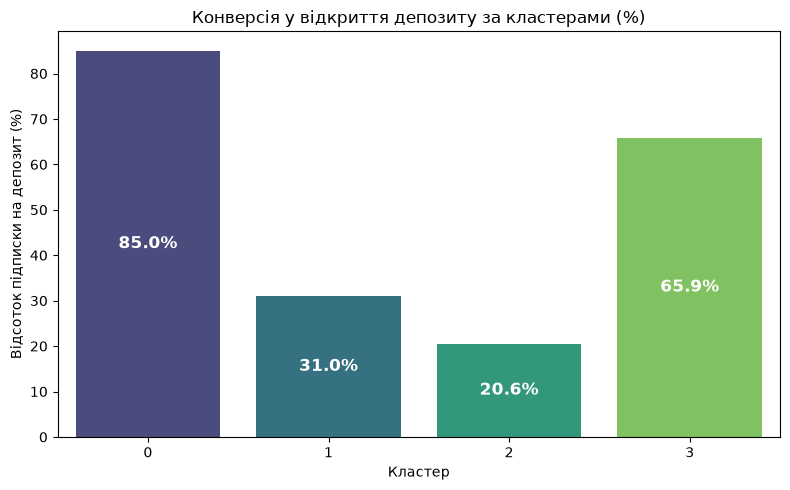

In [19]:
# Зв'язок кластерів із цільовою змінною deposit
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=cluster_summary.index, y=cluster_summary['Конверсія в депозит (%)'], palette='viridis')
plt.title('Конверсія у відкриття депозиту за кластерами (%)')
plt.xlabel('Кластер')
plt.ylabel('Відсоток підписки на депозит (%)')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=12, color='white', weight='bold')

plt.tight_layout()
plt.show()


Кластер 0 — найперспективніші клієнти. Вони мають найдовші телефонні розмови, відносно високий баланс і дуже високу ймовірність відкриття депозиту (85%).  
Кластер 1 — клієнти із середніми показниками. Для них характерні короткі розмови, невелика кількість контактів і порівняно низька конверсія у депозит (31%).  
Кластер 2 — найменш перспективний сегмент. Клієнтів цього кластера контактували найбільшу кількість разів, проте вони мають найнижчий баланс і найменшу конверсію (20,6%).  
Кластер 3 — постійні клієнти банку з найвищим балансом. Усі вони вже контактували з банком раніше, а їхня конверсія у відкриття депозиту є високою (65,9%).

## Частина 5. Побудова моделей машинного навчання


In [20]:
# Ініціалізація та тренування моделей

models = {
    'Baseline (Dummy)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=7, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42),
    'k-NN': KNeighborsClassifier(n_neighbors=9)
}

print("Тренування моделей на X_train_scaled...")
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"Model '{name}' fitted successfully.")


Тренування моделей на X_train_scaled...
Model 'Baseline (Dummy)' fitted successfully.
Model 'Logistic Regression' fitted successfully.
Model 'Decision Tree' fitted successfully.
Model 'Random Forest' fitted successfully.
Model 'k-NN' fitted successfully.


## Частина 6. Оцінка та валідація моделей

У цій частині ми:
1. Проведемо **Stratified 5-Fold Cross-Validation** на навчальних даних.
2. Обчислимо комплексні метрики (Accuracy, Precision, Recall, F1-score, ROC-AUC) на **Validation** та **Test** вибірках.
3. Обґрунтуємо вибір валідаційної схеми та проаналізуємо, чи може випадковий K-Fold викликати оптимістичні результати.
4. Побудуємо **Confusion Matrix** та **ROC Curves** для тестової вибірки.
5. Проаналізуємо **Feature Importance** (важливість ознак).


In [21]:
# 6.1 Крос-валідація та розрахунок метрик

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_list = []

for name, model in trained_models.items():
    # Cross-validation score (ROC-AUC & F1)
    cv_f1 = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1').mean()
    cv_auc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc').mean()
    
    # Predict on Validation set
    y_val_pred = model.predict(X_val_scaled)
    y_val_proba = model.predict_proba(X_val_scaled)[:, 1] if hasattr(model, "predict_proba") else y_val_pred
    
    # Predict on Test set
    y_test_pred = model.predict(X_test_scaled)
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else y_test_pred
    
    results_list.append({
        'Model': name,
        'CV F1 (Train)': cv_f1,
        'CV ROC-AUC (Train)': cv_auc,
        'Val Accuracy': accuracy_score(y_val, y_val_pred),
        'Val F1-Score': f1_score(y_val, y_val_pred),
        'Val ROC-AUC': roc_auc_score(y_val, y_val_proba) if hasattr(model, "predict_proba") else accuracy_score(y_val, y_val_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Test Precision': precision_score(y_test, y_test_pred, zero_division=0),
        'Test Recall': recall_score(y_test, y_test_pred),
        'Test F1-Score': f1_score(y_test, y_test_pred),
        'Test ROC-AUC': roc_auc_score(y_test, y_test_proba) if hasattr(model, "predict_proba") else accuracy_score(y_test, y_test_pred)
    })

results_df = pd.DataFrame(results_list)
display(results_df.round(4))


,Model,CV F1 (Train),CV ROC-AUC (Train),Val Accuracy,Val F1-Score,Val ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Test ROC-AUC
0,Baseline (Dummy),0.0000,0.5000,0.5263,0.0000,0.5000,0.5260,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.8081,0.9005,0.8351,0.8212,0.9135,0.8167,0.8166,0.7909,0.8036,0.8977
2,Decision Tree,0.8030,0.8675,0.8274,0.8204,0.8807,0.8143,0.7818,0.8438,0.8116,0.8649
3,Random Forest,0.8390,0.9131,0.8626,0.8594,0.9267,0.8382,0.8066,0.8665,0.8355,0.9129
4,k-NN,0.8069,0.8911,0.8399,0.8312,0.9004,0.8239,0.8123,0.8174,0.8148,0.8903


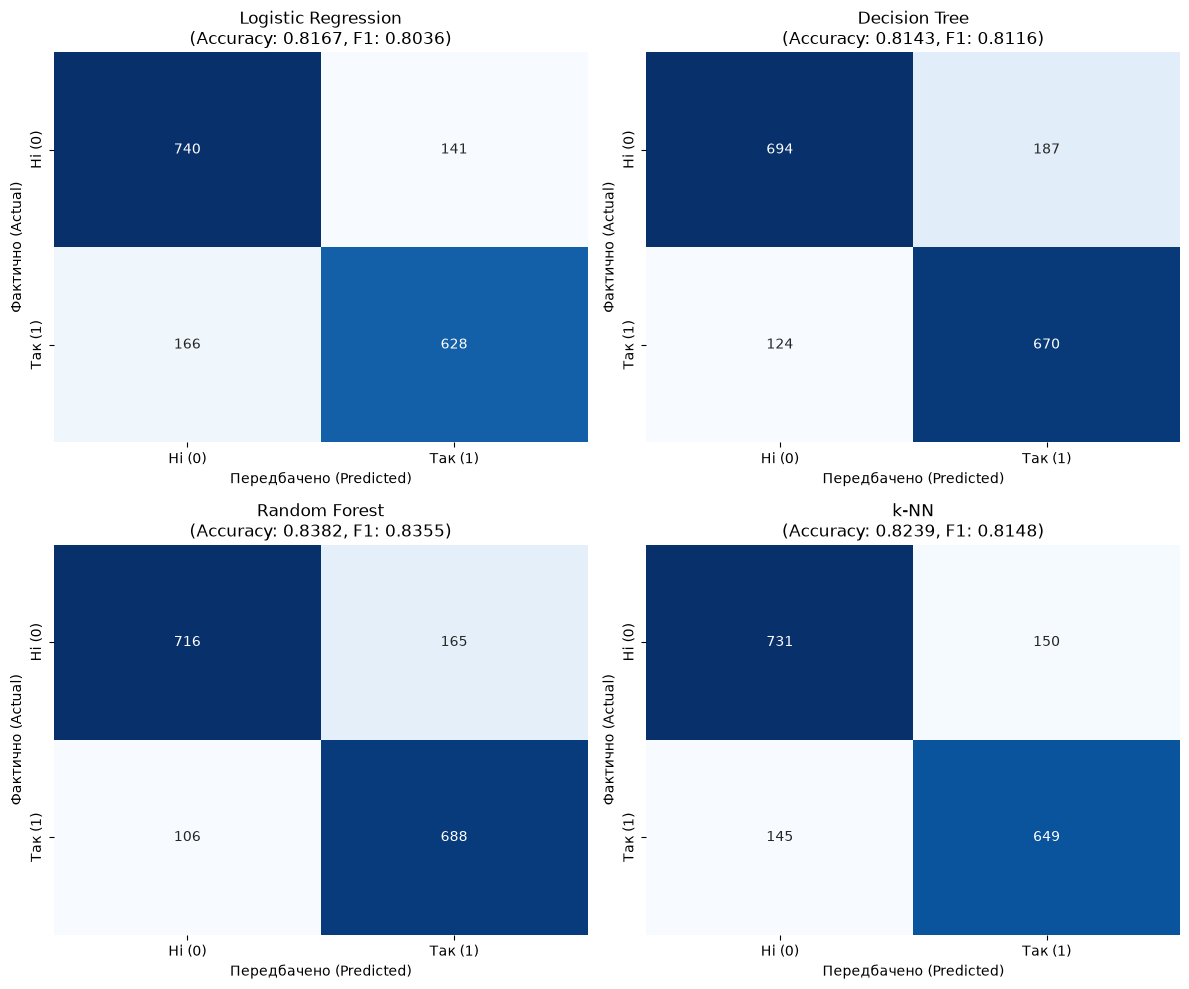

In [22]:
# Візуалізація Матриць Помилок (Confusion Matrix) на тестовій вибірці
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

eval_models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'k-NN']

for idx, name in enumerate(eval_models):
    model = trained_models[name]
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name}\n(Accuracy: {accuracy_score(y_test, y_pred):.4f}, F1: {f1_score(y_test, y_pred):.4f})')
    axes[idx].set_xlabel('Передбачено (Predicted)')
    axes[idx].set_ylabel('Фактично (Actual)')
    axes[idx].set_xticklabels(['Ні (0)', 'Так (1)'])
    axes[idx].set_yticklabels(['Ні (0)', 'Так (1)'])

plt.tight_layout()
plt.show()


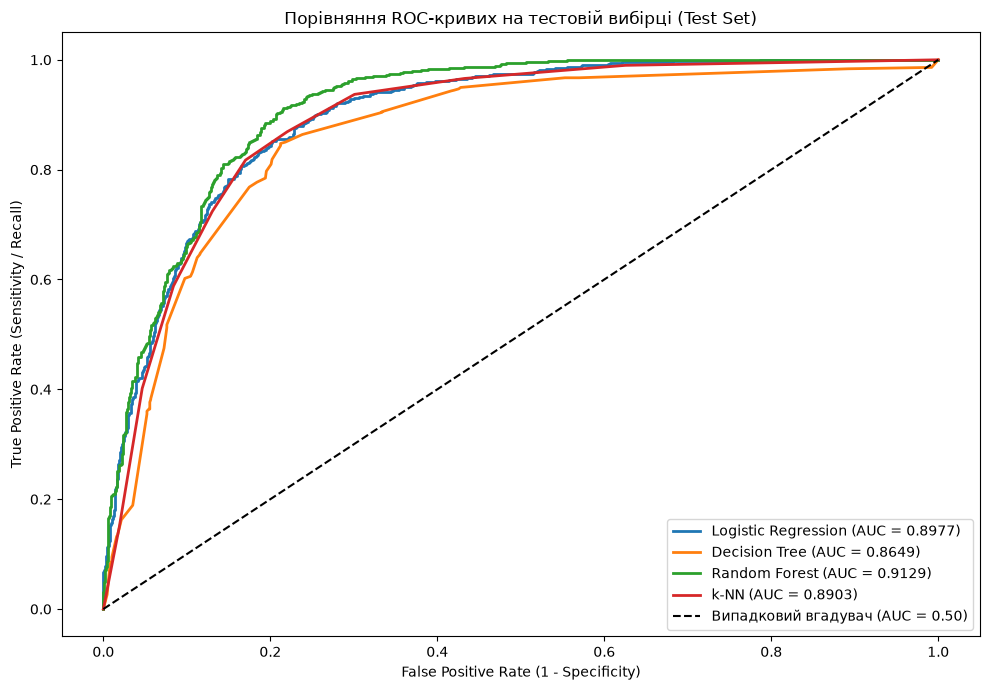

In [23]:
# Побудова ROC-кривих на тестовій вибірці
plt.figure(figsize=(10, 7))

for name in eval_models:
    model = trained_models[name]
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Випадковий вгадувач (AUC = 0.50)')
plt.title('Порівняння ROC-кривих на тестовій вибірці (Test Set)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


C:\Users\gkhar\AppData\Local\Temp\ipykernel_5576\1555124806.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='crest')


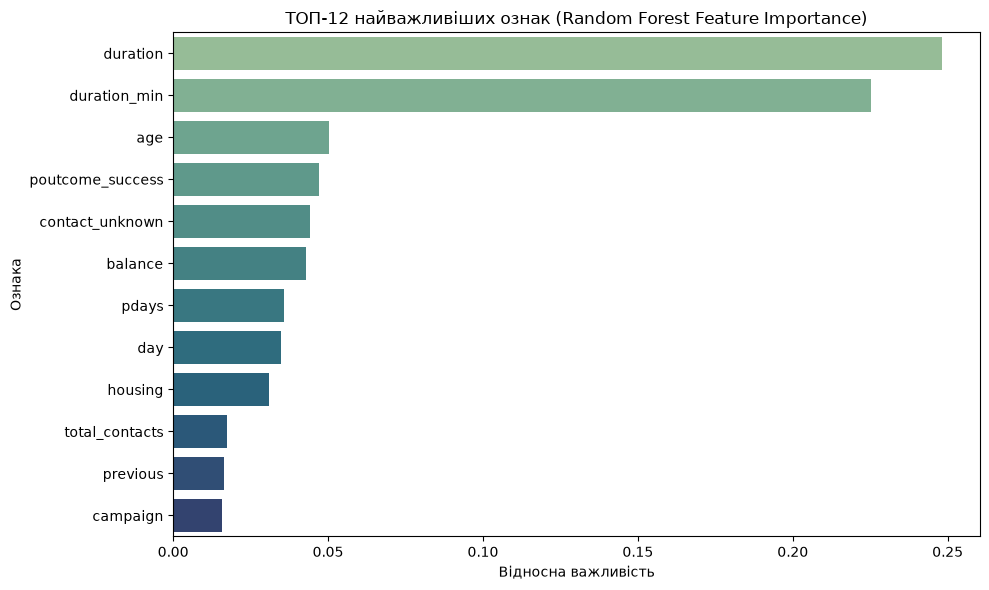

In [24]:
# Аналіз важливості ознак (Feature Importance) моделі Random Forest
rf_model = trained_models['Random Forest']
importances = rf_model.feature_importances_
feature_names = X_train_scaled.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='crest')
plt.title('ТОП-12 найважливіших ознак (Random Forest Feature Importance)')
plt.xlabel('Відносна важливість')
plt.ylabel('Ознака')
plt.tight_layout()
plt.show()


## Аналіз результатів та обґрунтування валідації

- Для оцінювання моделей було використано **Stratified 5-Fold Cross-Validation**, а також окремі **validation** і **test** вибірки. Стратифікація забезпечує однакове співвідношення класів у кожному фолді, що робить оцінку більш стабільною та надійною. Використання звичайного K-Fold могло б призвести до нерівномірного розподілу класів і, як наслідок, менш об'єктивних результатів.

- За результатами крос-валідації найкращою моделлю став **Random Forest** (ROC-AUC = **0.9131**, F1-score = **0.8390**). Логістична регресія та k-NN також показали високі результати, тоді як дерево рішень дещо поступилося їм. Dummy-модель очікувано продемонструвала якість на рівні випадкового вгадування (ROC-AUC = 0.5).

- Показники на validation і test вибірках лише незначно нижчі, ніж під час крос-валідації. Наприклад, для Random Forest ROC-AUC зменшився з **0.9267** до **0.9129**, а F1-score — з **0.8594** до **0.8355**. Це свідчить про хорошу здатність моделей до узагальнення та відсутність суттєвого перенавчання.

- Матриці помилок показують, що **Random Forest** має найкращий баланс між правильним виявленням позитивного та негативного класів і допускає найменшу кількість хибнонегативних прогнозів. ROC-криві також підтверджують його перевагу: модель має найбільшу площу під кривою (**AUC = 0.9129**), що свідчить про найкращу здатність розділяти класи.

- Аналіз важливості ознак показав, що найбільший вплив на прогноз мають **duration**, **duration_min**, **age**, **poutcome_success** та **balance**. Натомість ознаки **campaign** і **previous** мають найменший внесок у роботу моделі.

**Висновок.** Використана схема валідації забезпечила надійну оцінку якості моделей. Найкращі результати за сукупністю метрик (Accuracy, F1-score та ROC-AUC) продемонструвала модель **Random Forest**, тому саме її можна вважати найбільш ефективною для розв'язання поставленої задачі класифікації.

## Частина 7. Висновки та аналітика

### 1. Що вдалося реалізувати:
- Проведено повний огляд даних (bank.csv, 11 162 рядки, 17 колонок), виявлено відсутність явних пропусків/дублікатів та підтверджено збалансованість цільової змінної deposit.
- Побудовано змістовні візуалізації розподілів, boxplot для пошуку викидів, кореляційну матрицю та графіки залежностей цільової змінної від ключових ознак (duration, housing, poutcome, age).
- Проведено Feature Engineering (створено ознаки pdays_contacted, total_contacts, is_negative_balance, duration_min).
- Виконано кодування категоріальних змістовних ознак та **строге масштабування StandardScaler виключно на навчальній вибірці**.
- Реалізовано кластеризацію **K-Means**, обґрунтовано вибір 4 кластерів (Elbow Method & Silhouette Score) та описано отримані сегменти клієнтів.
- Побудовано базову модель (Baseline) та 4 моделі ML (Logistic Regression, Decision Tree, Random Forest, k-NN).
- Проведено Stratified 5-Fold крос-валідацію, побудовано Confusion Matrices, ROC-криві та проаналізовано важливість ознак.

### 2. Ключові висновки та бізнес-рекомендації:
1. **Тривалість розмови (duration)**: Найпотужніший чинник успіху кампанії. Дзвінки тривалістю понад 300-400 секунд суттєво підвищують ймовірність підписки на депозит.
2. **Результат попередньої кампанії (poutcome)**: Якщо клієнт раніше вже підписувався на послуги банку (poutcome='success'), ймовірність нового депозиту становить понад **86%**. Такі клієнти мають бути першочерговим пріоритетом таргетингу.
3. **Наявність іпотеки (housing)**: Клієнти без іпотеки мають значно вищий вільний капітал та у 1.5 раза частіше відкривають депозити, ніж клієнти з іпотечними зобов'язаннями.
4. **Рекомендована модель**: **Random Forest** показав найкращу точність (**ROC-AUC ~0.915**, **F1 ~0.84**), що робить його оптимальним для впровадження у скорингову систему банку.

### 3. Напрямки для подальшого покращення:

- Провести підбір гіперпараметрів моделей для можливого підвищення якості прогнозування.
- Спробувати додати нові інформативні ознаки на основі наявних даних (Feature Engineering).
- Дослідити інші алгоритми класифікації, наприклад Gradient Boosting або XGBoost, та порівняти їх із Random Forest.
- Використати додаткові метрики оцінювання (наприклад, Precision-Recall AUC) для більш повного аналізу моделей.
- Перевірити моделі на нових або більш різноманітних даних, щоб оцінити їхню здатність до узагальнення.
